In [49]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [59]:
df = pd.read_csv("hamon_googlefit_medical_realistic.csv")
df.head()

,user_id,age,sex,bmi,smoking_status,family_history_cvd,fitness_level,height_m,weight_kg,date,...,body_temp_c,sleep_hours,sleep_efficiency,fatigue_score,calories_consumed,water_intake_l,sleep_data_available,bp_measured,glucose_measured,cardiometabolic_risk_state
0,1,23,1,30.753735,0,1,1,1.525007,71.532157,2024-01-01,...,36.7,7.58540,0.93389,4,2246,2.6,True,True,False,2
1,1,23,1,30.753735,0,1,1,1.525007,71.499318,2024-01-02,...,36.4,NaN,NaN,3,2497,2.3,False,False,False,2
2,1,23,1,30.753735,0,1,1,1.525007,71.507641,2024-01-03,...,36.7,7.01264,0.91370,5,2648,1.8,True,False,True,2
3,1,23,1,30.753735,0,1,1,1.525007,71.470106,2024-01-04,...,36.6,NaN,NaN,3,2923,2.1,False,False,True,2
4,1,23,1,30.753735,0,1,1,1.525007,71.475484,2024-01-05,...,36.3,NaN,NaN,4,2372,2.8,False,True,False,2


#### 1. Überblick
- Wie viele Tage Daten hast du?
- Durchschnittliche:
  - Schritte pro Tag
  - Kalorien
  - Distanz

Herausfinden, wie viele Tage vorhanden sind

In [19]:
days = df["date"].nunique() # zählt distinct Werte
days

30

In [20]:
days = df.groupby("date").size().count()
days

30

Nachforschen, ob wirklich alle User 30 Tage Daten haben.

In [ ]:
# User finden, die keine 30 Tage Daten haben

df.groupby("user_id")["date"].nunique().loc[lambda x: x != 30]

Series([], Name: date, dtype: int64)

In [ ]:
# Herausfinden, ob wirklich alle User 30 Tage haben
# True = Alle haben 30 Tage - False = mind. einer hat keine 30 Tage

(df.groupby("user_id")["date"].nunique() == 30).all()

True

- Herausfinden, wie viele Schritte jeder User im Mittel gemacht hat
- Herausfinden, wie viele Schritte alle User im Mittel gemacht haben

In [ ]:
# Schritte pro Tag: 
df.groupby("user_id")["steps"].sum() / days

#BESSER, weil fehlerunanfälliger, wenn bspw. nicht jeder 30 Tage Daten hat
df.groupby("user_id")["steps"].mean()

user_id
1        7551.600000
2        9281.700000
3        3512.100000
4        5079.233333
5       10799.233333
            ...     
2996     8257.900000
2997     5338.800000
2998     8022.633333
2999     6900.166667
3000     6741.933333
Name: steps, Length: 3000, dtype: float64

In [21]:
df["steps"].mean()

6611.218988888889

In [24]:
df.groupby("user_id")["steps"].mean().mean()

6611.21898888889

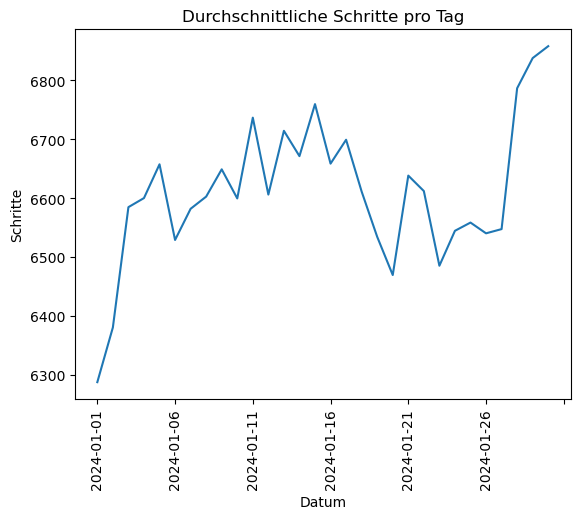

In [53]:
# Mittelwert je Tag
daily_avg = df.groupby("date")["steps"].mean()

daily_avg.plot()
plt.title("Durchschnittliche Schritte pro Tag")
plt.xlabel("Datum")
plt.ylabel("Schritte")
plt.xticks(rotation=90)
plt.show()

- Herausfinden, wie viele Kalorien verbrannt wurden, für jeden User und Mittelwert aller User

In [ ]:
# Wert pro User
df.groupby("user_id")["calories_burned"].mean()

user_id
1       1934.600000
2       1980.966667
3       1748.200000
4       1789.233333
5       2049.566667
           ...     
2996    1946.266667
2997    1813.700000
2998    1951.600000
2999    1878.600000
3000    1866.100000
Name: calories_burned, Length: 3000, dtype: float64

In [ ]:
# Mittelwert aller User
df.groupby("user_id")["calories_burned"].mean().mean()

1864.427611111111

- Herausfinden, wie viele Kalorien zugenommen wurden, für jeden User und Mittelwert aller User

In [ ]:
# Wert pro User
df.groupby("user_id")["calories_consumed"].mean()

user_id
1       2495.266667
2       2392.466667
3       2460.733333
4       2444.733333
5       2540.900000
           ...     
2996    2404.633333
2997    2489.966667
2998    2557.433333
2999    2371.666667
3000    2425.600000
Name: calories_consumed, Length: 3000, dtype: float64

In [ ]:
# Mittelwert aller User
df.groupby("user_id")["calories_consumed"].mean().mean()

2461.526977777778

- Herausfinden wie viele KM Distanz jeder User überwunden hat, pro User und insgesamt

In [ ]:
# pro User
df.groupby("user_id")["distance_km"].mean()

user_id
1       5.663667
2       6.962333
3       2.634000
4       3.809333
5       8.099667
          ...   
2996    6.193667
2997    4.004000
2998    6.016667
2999    5.176000
3000    5.056333
Name: distance_km, Length: 3000, dtype: float64

In [ ]:
# Mittelwert aller User
df.groupby("user_id")["distance_km"].mean().mean()

4.958455999999999

#### 2. Aktivster Tag
- An welchem Tag hattest du:
    - die meisten Schritte?
    - die meisten Kalorien?

- Herausfinden an welchem Tag jeder User die meisten Schritte getan hat

In [ ]:
# gibt das Maximum an Schritten pro User aus
df.groupby("user_id")["steps"].max()

user_id
1       13472
2       14479
3        9311
4       11449
5       15084
        ...  
2996    15966
2997    11063
2998    12863
2999    13822
3000    12238
Name: steps, Length: 3000, dtype: int64

In [54]:
# gibt das Maximum an Schritten pro User aus, inklusive Datum des Tages
idx = df.groupby("user_id")["steps"].idxmax()

df.loc[idx, ["user_id", "date", "steps"]]

,user_id,date,steps
18,1,2024-01-19,13472
32,2,2024-01-03,14479
79,3,2024-01-20,9311
92,4,2024-01-03,11449
135,5,2024-01-16,15084
...,...,...,...
89864,2996,2024-01-15,15966
89903,2997,2024-01-24,11063
89921,2998,2024-01-12,12863
89946,2999,2024-01-07,13822


- Herausfinden an welchem Tag jeder User die meisten Kalorien verbrannt und was er an selbigen zu sich genommen hat

In [ ]:
# sucht den max index aus der Spalte der konsumierten Kalorien
idx = df.groupby("user_id")["calories_consumed"].idxmax()

df.loc[idx, ["user_id", "date", "calories_consumed", "calories_burned"]]

,user_id,date,calories_consumed,calories_burned
24,1,2024-01-25,2978,1873
34,2,2024-01-05,3300,1888
79,3,2024-01-20,2952,1891
118,4,2024-01-29,3182,1669
139,5,2024-01-20,3077,2109
...,...,...,...,...
89859,2996,2024-01-10,2913,2144
89890,2997,2024-01-11,3139,1460
89925,2998,2024-01-16,3072,2113
89969,2999,2024-01-30,2781,1859


In [45]:
# sucht den max index aus der Spalte der konsumierten Kalorien
idx = df.groupby("user_id")["calories_burned"].idxmax()

df.loc[idx, ["user_id", "date", "calories_burned", "calories_consumed"]]

,user_id,date,calories_burned,calories_consumed
1,1,2024-01-02,2337,2497
36,2,2024-01-07,2371,2165
78,3,2024-01-19,2114,2779
92,4,2024-01-03,2192,2471
128,5,2024-01-09,2315,1859
...,...,...,...,...
89866,2996,2024-01-17,2351,2670
89903,2997,2024-01-24,2146,2484
89916,2998,2024-01-07,2238,2528
89953,2999,2024-01-14,2305,2216


#### 3. Wochentage vs Wochenende
- Vergleich:
    - Schritte (Mo–Fr vs Sa–So)


Insight: „Bin ich am Wochenende aktiver?“

In [61]:
# Datum in Wochentag umwandeln
df["date"] = pd.to_datetime(df["date"])

df["weekday"] = df["date"].dt.day_name()

In [ ]:
# Wochenende vs. Wochentag in neuer Spalte teilen
df["is_weekend"] = df["date"].dt.weekday >= 5


In [ ]:
# betrachtet alle User und gibt Mittelwert für Wochentage und Wochenende zurück
df.groupby("is_weekend")["steps"].mean()

is_weekend
False    6609.075364
True     6617.113958
Name: steps, dtype: float64

Insight: Wochentage und Wochenenden unterscheiden sich kaum in der Aktivität. Im Durchschnitt. 

In [68]:
# True = Wochenende
# False = Wochentag
df.groupby(["user_id", "is_weekend"])["steps"].mean().unstack()

is_weekend,False,True
user_id,,
1,7164.272727,8616.750
2,9536.590909,8580.750
3,3560.636364,3378.625
4,4831.818182,5759.625
5,11074.272727,10042.875
...,...,...
2996,8562.954545,7419.000
2997,4335.454545,8098.000
2998,7655.954545,9031.000


#### 4. Trendanalyse
- Entwickeln sich deine Schritte über die Zeit?
- Wirst du aktiver?

#### 5. Korrelationen
- Zusammenhang zwischen:
    - Schritte ↔ Kalorien
    - Distanz ↔ Kalorien

Frage: „Verbrenne ich wirklich mehr, wenn ich mehr laufe?“

#### 6. Aktivitätsanalyse
- Welche Aktivität verbrennt am meisten Kalorien?
- Durchschnittliche Dauer je Aktivität

#### 7. Zielerreichung 🎯
- Definiere Ziel: z. B. 10.000 Schritte/Tag
- Wie oft erreichst du es?

KPI: Goal Achievement Rate (%)

#### 8. Beste Tageszeit für Aktivität
- Wann bist du am aktivsten?
  - Morgen / Nachmittag / Abend

#### 9. Ausreißer finden
- Tage mit:
  - extrem wenig Bewegung
  - extrem hoher Aktivität

Interpretation: Krankheit? Workout? Fehler?

#### 10. Nutzerverhalten segmentieren

Teile Tage ein in:

- Low Activity
- Medium
- High Activity

Frage: „Wie oft bin ich in welchem Zustand?“

#### 11. Habit-Analyse
- Wie viele Tage in Folge bist du aktiv?
- Gibt es „Drop-offs“?

Insight: „Wo verliere ich meine Routine?“ 

#### 12.Engagement-Score bauen

Erstelle eine Metrik wie: Score = Schritte + Kalorien * Gewichtung

Ziel:
- Tage vergleichen
- Fortschritt messen

#### 13. Storytelling

Beantworte: „Was sind die 3 wichtigsten Erkenntnisse aus meinen Fitness-Daten?“

#### 14. Dashboard bauen

Zeige:
- KPI: Ø Schritte
- Trend: Aktivität über Zeit
- Breakdown: Aktivitätstypen
- Zielerreichung